**Consider Sales dataset and analyse it in a proper way.**

**Expectation: need a clarity on who is spending more money for shopping incase of gender,age_group,state,Occupation,Product_category,marital_status.**

In [45]:
#importing all the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
#Read the data frame
df=pd.read_csv("https://github.com/Kalai865/Data_Analysis/raw/refs/heads/main/Datasets/sales_data.csv",encoding="ISO-8859-1")
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [48]:
#Fetching null data from Amount column
df[df["Amount"].isnull()]

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
14,1003858,Cano,P00293742,M,46-50,46,1,Madhya Pradesh,Central,Hospitality,Auto,3,NaN,NaN,NaN
16,1005447,Amy,P00275642,F,46-50,48,1,Andhra Pradesh,Southern,IT Sector,Auto,3,NaN,NaN,NaN
109,1005265,Sakshi,P00296242,F,46-50,48,1,Delhi,Central,Banking,Footwear & Shoes,1,NaN,NaN,NaN
111,1005261,Apoorva,P00057942,F,36-45,41,1,Delhi,Central,IT Sector,Footwear & Shoes,2,NaN,NaN,NaN
184,1005538,Kartik,P00269542,F,46-50,49,1,Karnataka,Southern,Banking,Footwear & Shoes,1,NaN,NaN,NaN
293,1000326,Jonathan,P00120542,M,51-55,53,0,Gujarat,Western,IT Sector,Footwear & Shoes,3,NaN,NaN,NaN
344,1002507,Lakshmi,P00045842,F,26-35,35,1,Gujarat,Western,Chemical,Furniture,1,NaN,NaN,NaN
345,1004498,Srishti,P00030842,F,51-55,55,0,Delhi,Central,Textile,Footwear & Shoes,1,NaN,NaN,NaN
452,1004601,Gaurav,P00014442,F,36-45,40,1,Madhya Pradesh,Central,Hospitality,Food,4,NaN,NaN,NaN


In [49]:
# drop unwanted columns
df=df.drop(["Status","unnamed1"],axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [50]:
#Delete all NaN values in the data frame
df.dropna(inplace=True)
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11239 non-null  int64  
 1   Cust_name         11239 non-null  object 
 2   Product_ID        11239 non-null  object 
 3   Gender            11239 non-null  object 
 4   Age Group         11239 non-null  object 
 5   Age               11239 non-null  int64  
 6   Marital_Status    11239 non-null  int64  
 7   State             11239 non-null  object 
 8   Zone              11239 non-null  object 
 9   Occupation        11239 non-null  object 
 10  Product_Category  11239 non-null  object 
 11  Orders            11239 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.2+ MB


In [52]:
#Rename the column Marital_Status to Marital
df.rename(columns={"Marital_Status":"Marital"},inplace=True)
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [53]:
#change the values in marital column 0-->single and 1-->married
df["Marital"]=df["Marital"].map({0:'single',1:'married'})
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,married,Gujarat,Western,Food Processing,Auto,2,23877.0


In [54]:
#change the values of gender column F-->Female and M-->Male
df["Gender"]=df["Gender"].map({"F":"Female","M":"Male"})
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,Female,26-35,28,single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,Female,26-35,35,married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,Female,26-35,35,married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,Male,0-17,16,single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,Male,26-35,28,married,Gujarat,Western,Food Processing,Auto,2,23877.0


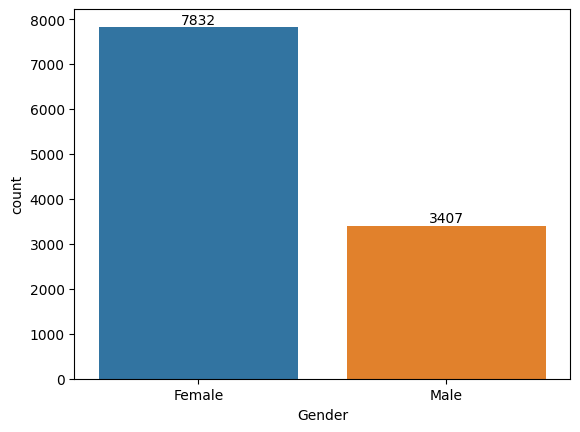

In [55]:
#visualize the count of males and females based on gender column using seaborn
a=sns.countplot(x="Gender",data=df,hue="Gender")
for i in a.containers:
   a.bar_label(i)


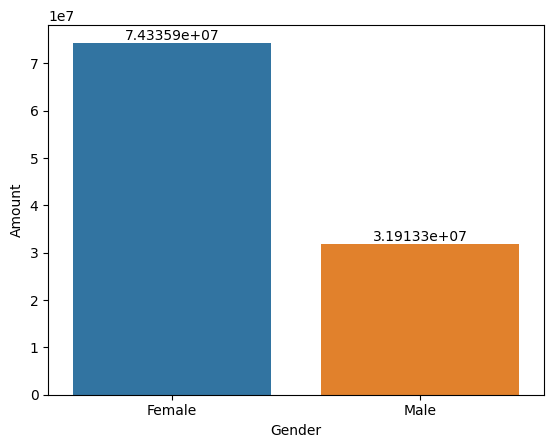

In [56]:
#group by gender
a=df.groupby("Gender")["Amount"].sum()
a=pd.DataFrame(a)

#visualize male and female  amount
a=sns.barplot(x="Gender",y="Amount",data=a,hue="Gender")
for i in a.containers:
  a.bar_label(i)

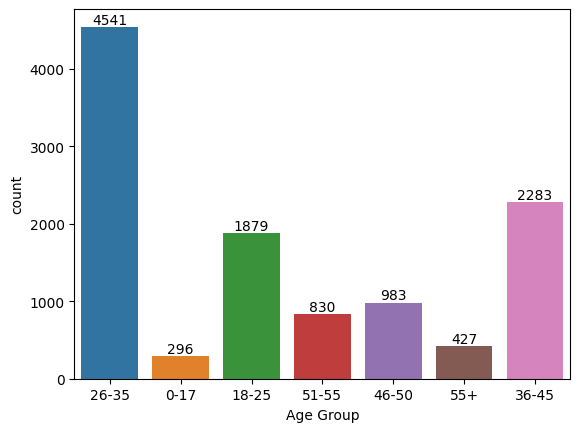

In [57]:
#count based on age group
v=sns.countplot(x="Age Group",data=df,hue="Age Group")
for i in v.containers:
  v.bar_label(i)

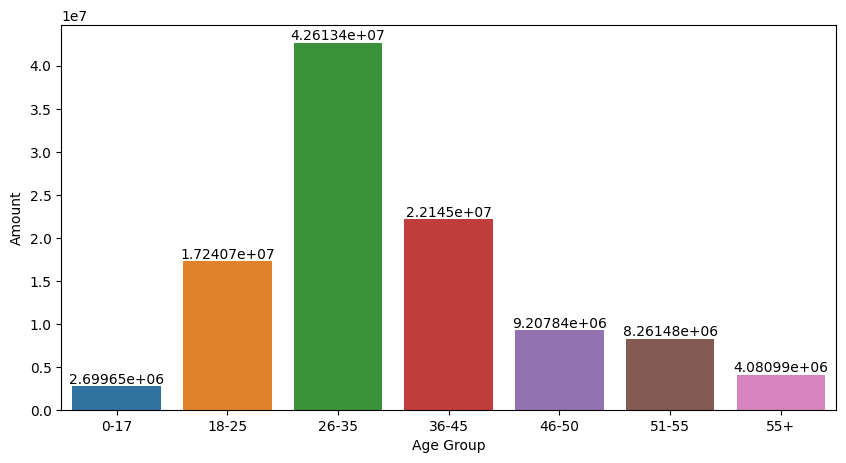

In [58]:
#group by age group
a=df.groupby("Age Group")["Amount"].sum()
a=pd.DataFrame(a)
plt.figure(figsize=(10,5))
b=sns.barplot(x="Age Group",y="Amount",data=a,hue="Age Group")
for i in b.containers:
  b.bar_label(i)

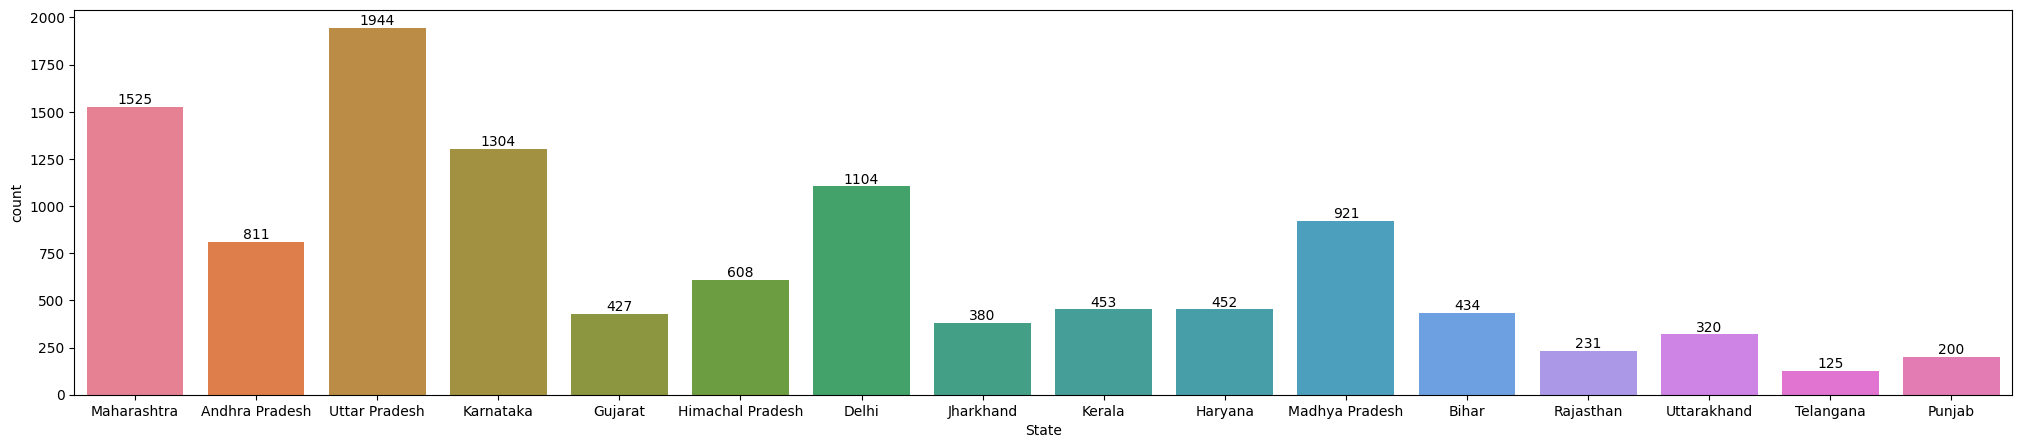

In [59]:
# count based on state
plt.figure(figsize=(25,5))
v=sns.countplot(x="State",data=df,hue="State")
for i in v.containers:
  v.bar_label(i)

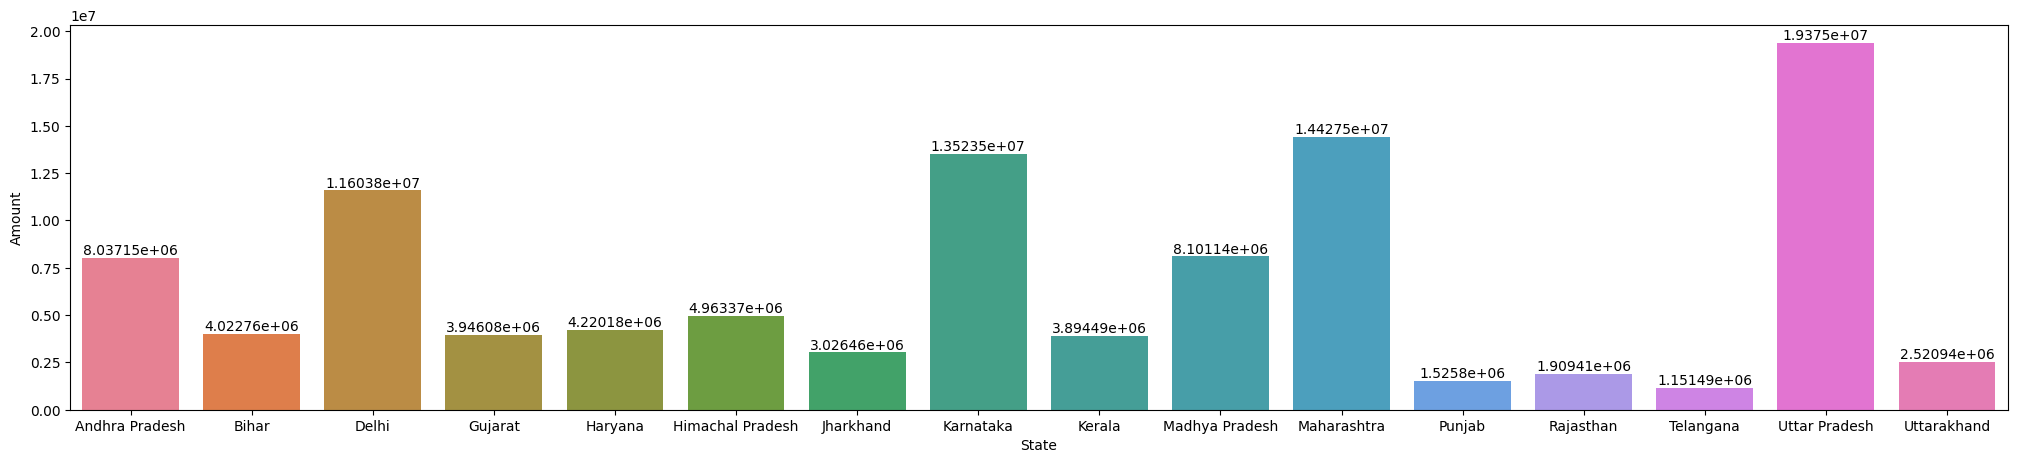

In [60]:
# group by state
a=df.groupby("State")["Amount"].sum()
a=pd.DataFrame(a)
plt.figure(figsize=(25,5))
v=sns.barplot(x="State",y="Amount",data=a,hue="State")
for i in v.containers:
  v.bar_label(i)

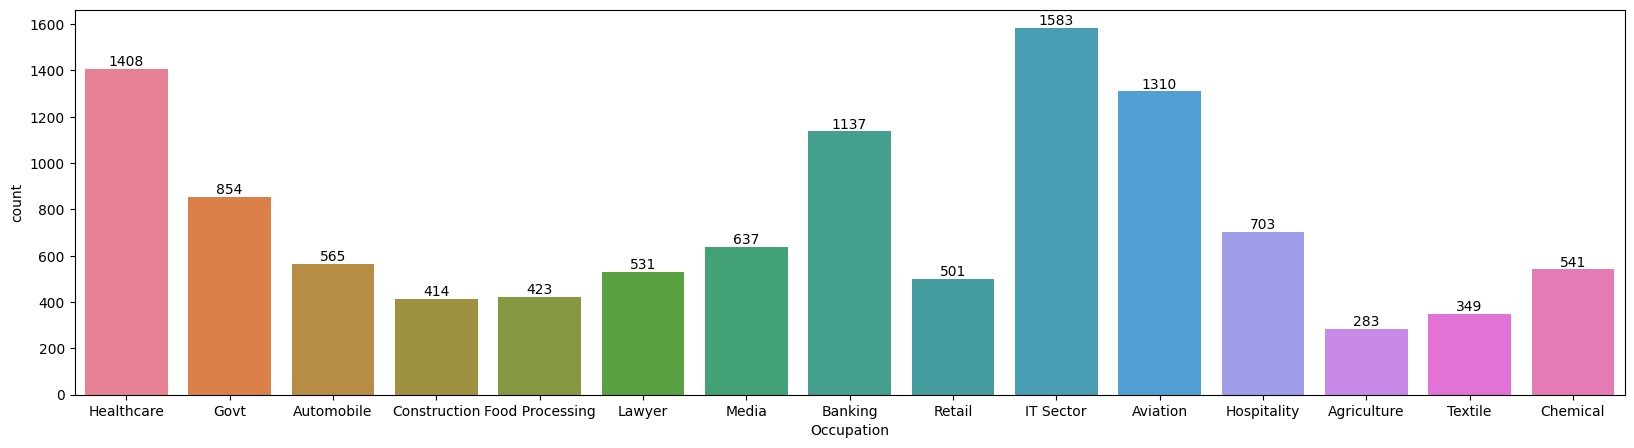

In [61]:
#count based on occupation
plt.figure(figsize=(20,5))
v=sns.countplot(x='Occupation',data=df,hue='Occupation')
for i in v.containers:
  v.bar_label(i)

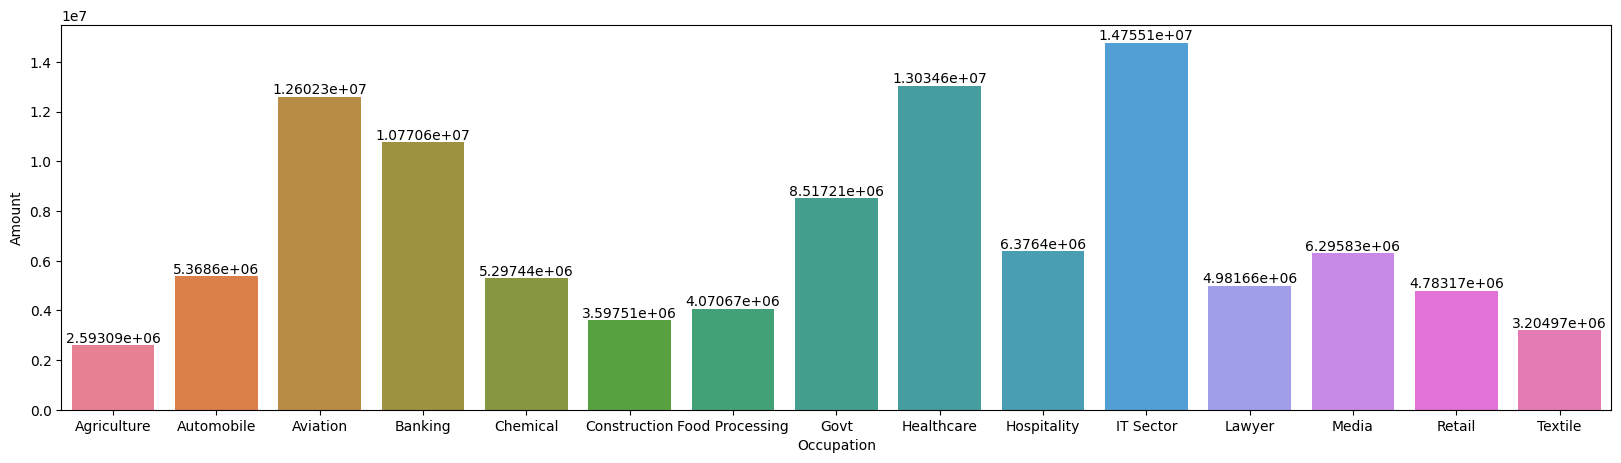

In [62]:
#group by occupation
a=df.groupby('Occupation')['Amount'].sum()
a=pd.DataFrame(a)
plt.figure(figsize=(20,5))
b=sns.barplot(x='Occupation',y='Amount',data=a,hue='Occupation')
for i in b.containers:
  b.bar_label(i)



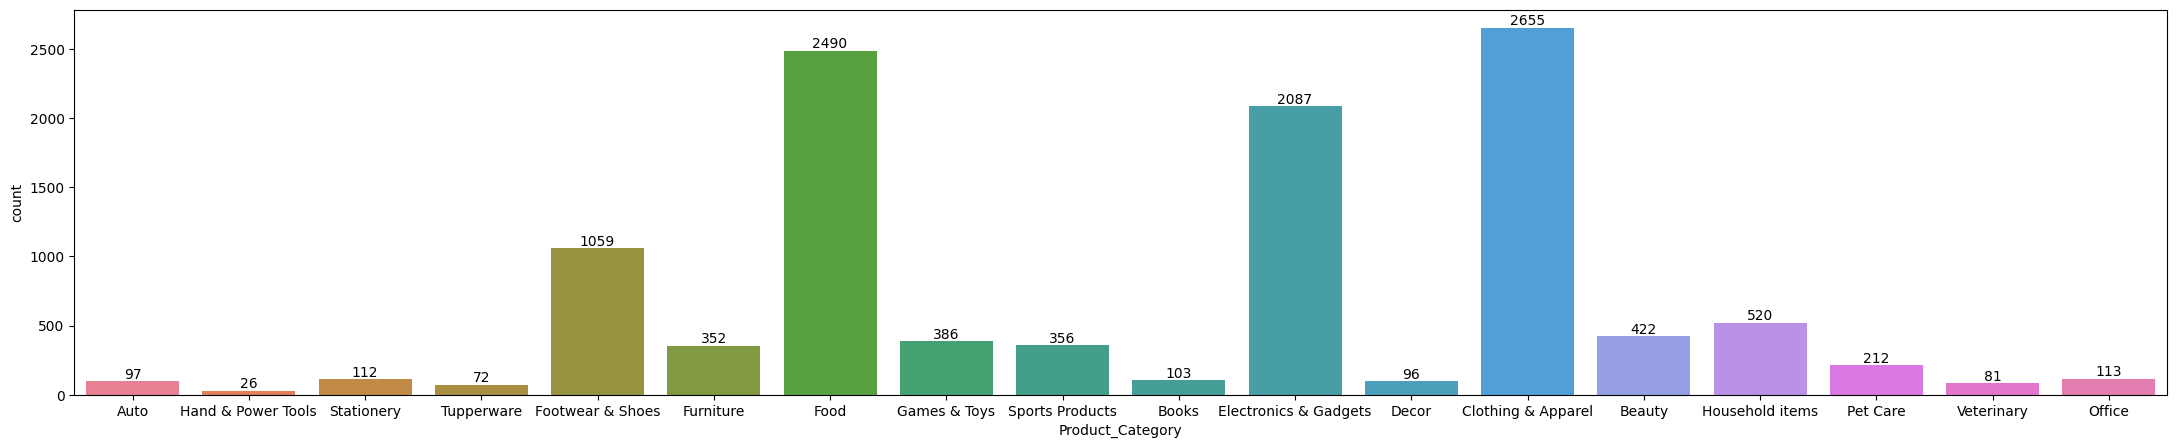

In [63]:
#count based on product_category col
plt.figure(figsize=(27,5))
v=sns.countplot(x='Product_Category',data=df,hue='Product_Category')
for i in v.containers:
  v.bar_label(i)

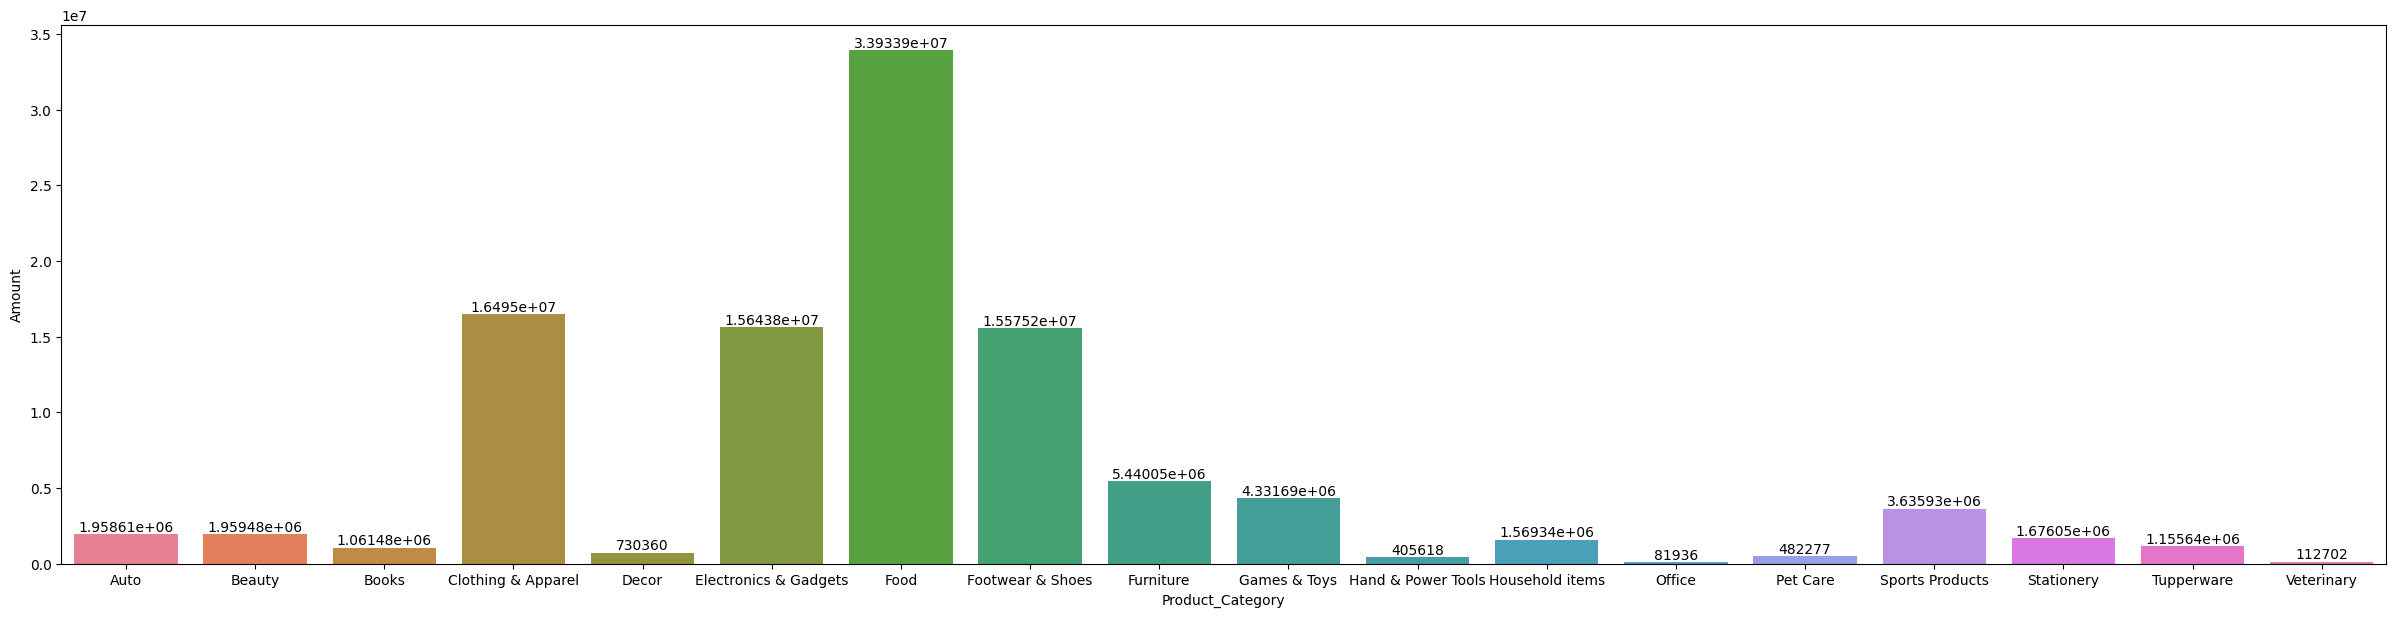

In [64]:
#groupby based on Product_Category
a=df.groupby('Product_Category')['Amount'].sum()
a=pd.DataFrame(a)
plt.figure(figsize=(30,7))
b=sns.barplot(x='Product_Category',y='Amount',data=a,hue='Product_Category')
for i in b.containers:
  b.bar_label(i)


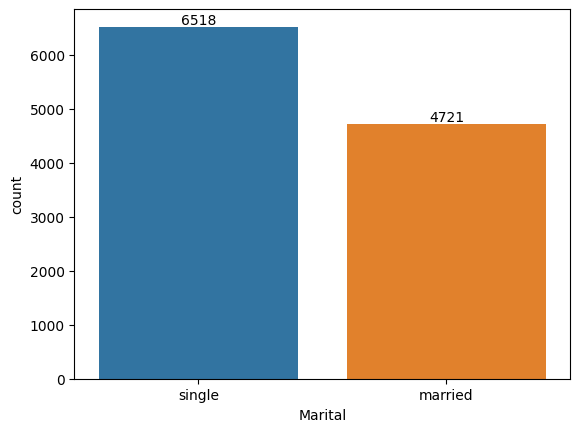

In [65]:
#count based on marital status
v=sns.countplot(x='Marital',data=df,hue='Marital')
for i in v.containers:
  v.bar_label(i)

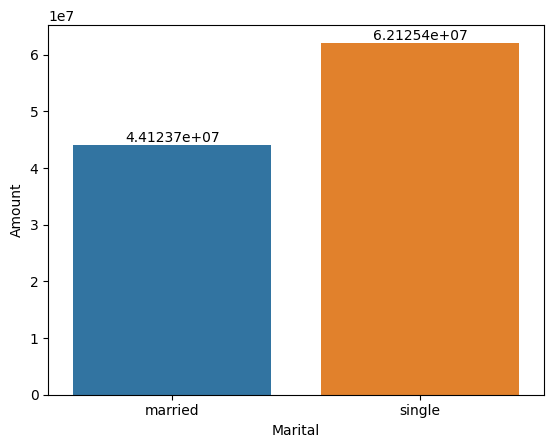

In [66]:
#groupby based on Marital
a=df.groupby('Marital')['Amount'].sum()
a=pd.DataFrame(a)
b=sns.barplot(x='Marital',y='Amount',data=a,hue='Marital')
for i in b.containers:
  b.bar_label(i)

**Conclusion: Based on the above analysis i can conclude that single females of age 26-35 from Uttar-pradesh,maharastra and karnataka working in IT,Healthcare and aviation spending more money on food,electronic gadgets,clothes and footware.**